In [2]:
import pandas as pd
import os
from neo4j import GraphDatabase
from dotenv import load_dotenv

load_dotenv("../.env")

NODES_DIR = "../data/nodes/"

class Config:
    def __init__(self, mode="LOCAL"):
        mode = mode.upper()

        if mode == "LOCAL":
            self.URI = os.getenv("NEO4J_URI_LOCAL")
            self.USER = os.getenv("NEO4J_USER_LOCAL")
            self.PASSWORD = os.getenv("NEO4J_PASSWORD_LOCAL")
        elif mode == "GROUP":
            self.URI = os.getenv("NEO4J_GROUP_URI")
            self.USER = os.getenv("NEO4J_GROUP_USER")
            self.PASSWORD = os.getenv("NEO4J_GROUP_PASSWORD")
        else:
            raise ValueError("Mode must be 'LOCAL' or 'GROUP'.")

        self.DATABASE = "neo4j"

config = Config(mode="LOCAL")
driver = GraphDatabase.driver(config.URI, auth=(config.USER, config.PASSWORD))

with driver.session(database=config.DATABASE) as session:
    session.run("MATCH (n) RETURN n LIMIT 1")
    print(f"Connection successful")

def query_neo4j(cypher_query: str, parameters: dict = None):
    with driver.session(database=config.DATABASE) as session:
        result = session.run(cypher_query, parameters)
        return result.data()

Connection successful


#### Step 1: Calculate `Business Success Score` per Block Group

Calculate based on :
- Number of Businesses
- Average Business Rating
- % 4+ Start Businesses

In [3]:
data = query_neo4j("""
   // 1. Compute per-block-group business metrics
   MATCH (bg:BlockGroup)<-[:CONTAINED_IN]-(b:BusinessLocation)
   RETURN
        bg,
        avg(b.avg_rating) AS avg_rating,
        count(b) AS num_businesses,
        count(CASE WHEN b.avg_rating >= 4 THEN 1 END) * 1.0 / count(b) AS pct_high_rating
""")

flat = [{
    **d["bg"],   # unpack all bg fields
    "avg_rating": d["avg_rating"],
    "num_businesses": d["num_businesses"],
    "pct_high_rating": d["pct_high_rating"]
} for d in data]


df = pd.DataFrame(flat)
print(df.shape)
df.head()

(1665, 41)


,x1001fy_x,n01_bus,n14_bus,n37_sales,countyfp,s23_emp,geom,blkgrpce,di150_cy,geo_id,...,ctblockgroup,di100_cy,centroid,medhinc_cy,gini_fy,ogc_fid,fem35,avg_rating,num_businesses,pct_high_rating
0,115362302.0,30.0,0.0,169.0,73,91.0,0106000020E610000001000000010300000001000000B8...,1,98,6.073000e+10,...,1001,120,0101000020E6100000F9DD3870B24B5DC0799CEE388760...,177856,23.9,1,32,4.800000,1,1.000000
1,179816406.0,59.0,0.0,12628.0,73,195.0,0106000020E61000000100000001030000000100000031...,2,159,6.073000e+10,...,1002,129,0101000020E6100000AFC67FB20C4C5DC02FD966214060...,200001,21.9,2,38,4.494118,17,0.941176
2,64440225.0,82.0,0.0,1080.0,73,345.0,0106000020E61000000100000001030000000100000088...,1,52,6.073000e+10,...,2011,123,0101000020E61000003299120A344B5DC0EC97B3AF9460...,126652,31.7,3,33,4.707692,13,1.000000
3,95423500.0,154.0,1.0,3819.0,73,333.0,0106000020E61000000100000001030000000100000062...,2,54,6.073000e+10,...,2012,155,0101000020E6100000779362E9F44A5DC00471F9E05B60...,86349,39.1,4,41,4.516667,48,0.875000
4,90161948.0,64.0,0.0,14428.0,73,100.0,0106000020E6100000010000000103000000010000008D...,1,77,6.073000e+10,...,2021,65,0101000020E610000037A66881594B5DC022ECE625385F...,58414,45.3,5,67,4.435294,17,0.882353


In [4]:
df["business_success_score"] = (
    (df["num_businesses"] / df["num_businesses"].max()) * 0.4 +
    (df["avg_rating"] / 5.0) * 0.4 +
    (df["pct_high_rating"]) * 0.2
)


df[["id", "num_businesses", "avg_rating", "pct_high_rating", "business_success_score"]].sort_values(by="business_success_score", ascending=False).head(10)

,id,num_businesses,avg_rating,pct_high_rating,business_success_score
593,85112,1039,4.334841,0.837344,0.914256
484,83501,748,4.428359,0.856952,0.813628
1119,162021,572,4.301421,0.798951,0.724116
1572,203131,428,4.340654,0.803738,0.672774
1487,200294,354,4.416949,0.881356,0.665912
1660,221012,342,4.265826,0.824561,0.637843
334,65001,328,4.281402,0.801829,0.629153
753,100152,405,4.112346,0.716049,0.628117
1321,175012,198,4.494444,0.919192,0.619621
426,82012,173,4.542197,0.924855,0.614949


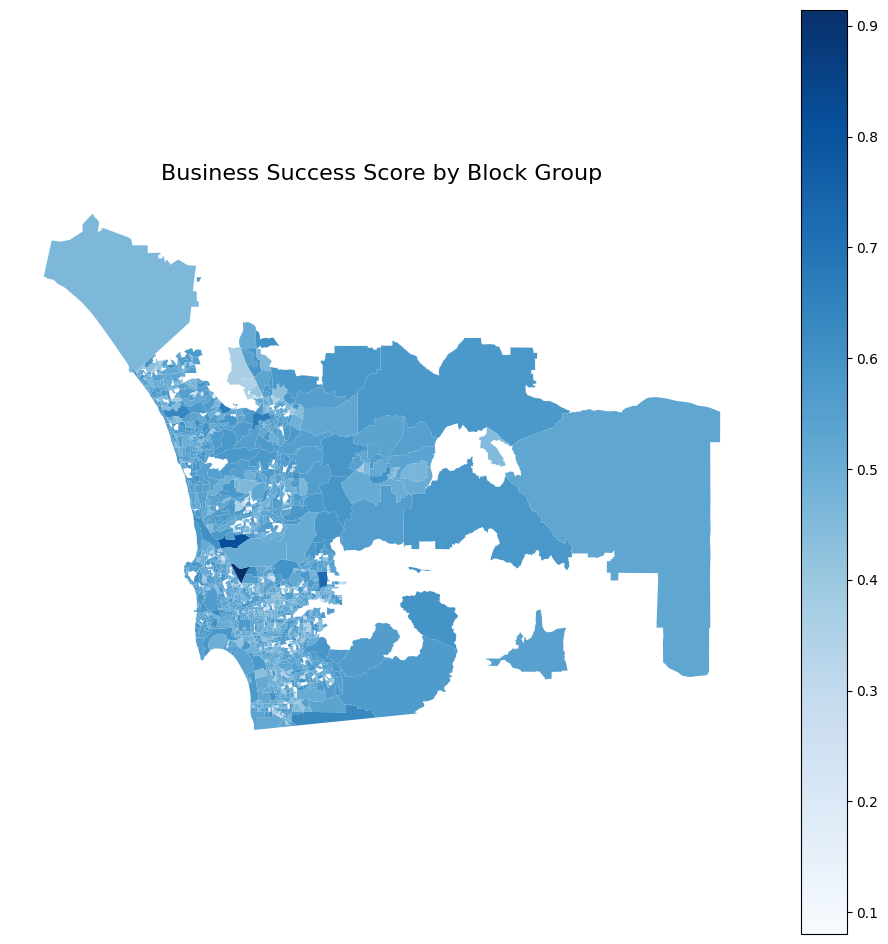

In [5]:
import pandas as pd
import geopandas as gpd
import folium

geometry = gpd.GeoSeries.from_wkt(df['geom_wkt'])

gdf = gpd.GeoDataFrame(
    df,
    crs="EPSG:4326",
    geometry=geometry
)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(12, 12))

gdf.plot(
    column="business_success_score",
    cmap="Blues",
    linewidth=0,
    edgecolor="none",
    legend=True,
    ax=ax
)

ax.set_title("Business Success Score by Block Group", fontsize=16)
ax.axis("off")

plt.show()

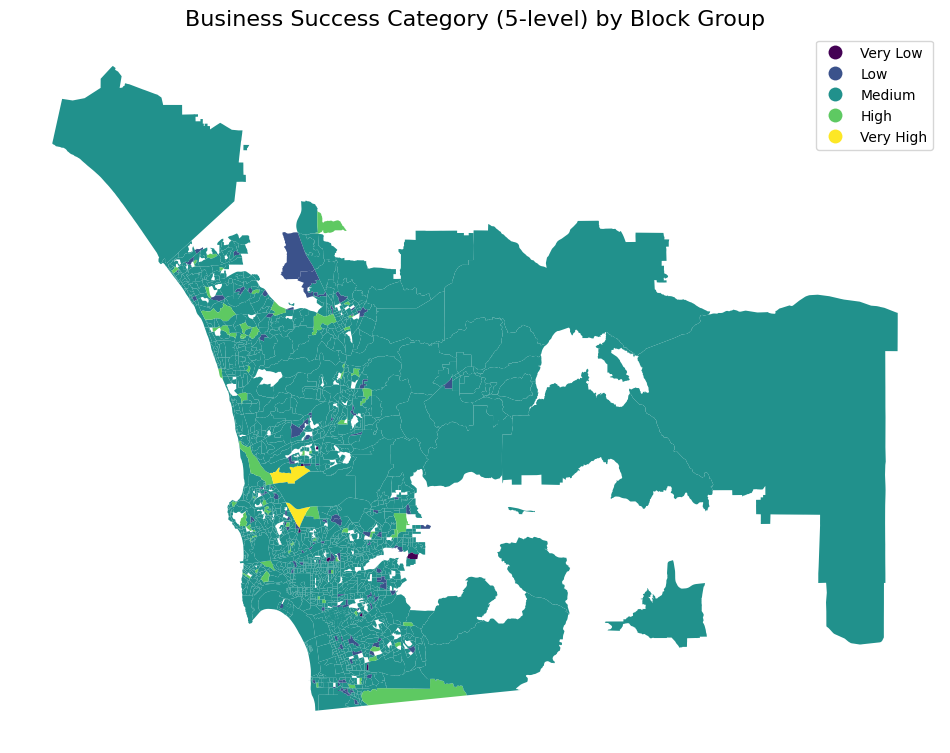

In [6]:
gdf["bss_category"] = pd.qcut(
    gdf["business_success_score"],
    q=5,
    labels=["Very Low", "Low", "Medium", "High", "Very High"]
)
gdf["bss_category"].value_counts()
bins = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
labels = ["Very Low", "Low", "Medium", "High", "Very High"]

gdf["bss_category"] = pd.cut(
    gdf["business_success_score"],
    bins=bins,
    labels=labels,
    include_lowest=True
)
fig, ax = plt.subplots(1, 1, figsize=(12, 12))

gdf.plot(
    column="bss_category",
    cmap="viridis",
    linewidth=0,
    edgecolor="none",
    legend=True,
    ax=ax
)

ax.set_title("Business Success Category (5-level) by Block Group", fontsize=16)
ax.axis("off")

plt.show()


#### Step 2: Find Similar Block Groups (Clustering)

Which block groups are most similar, based on attributes and demographics (Income, Age, etc)

{2: 0.7887706815881423, 3: 0.41318863559182134, 4: 0.39689831672448667, 5: 0.2996733492483586, 6: 0.3022870522685754, 7: 0.3056872273287335, 8: 0.39077971503035164, 9: 0.2944085677093166}
Optimal number of clusters: 2


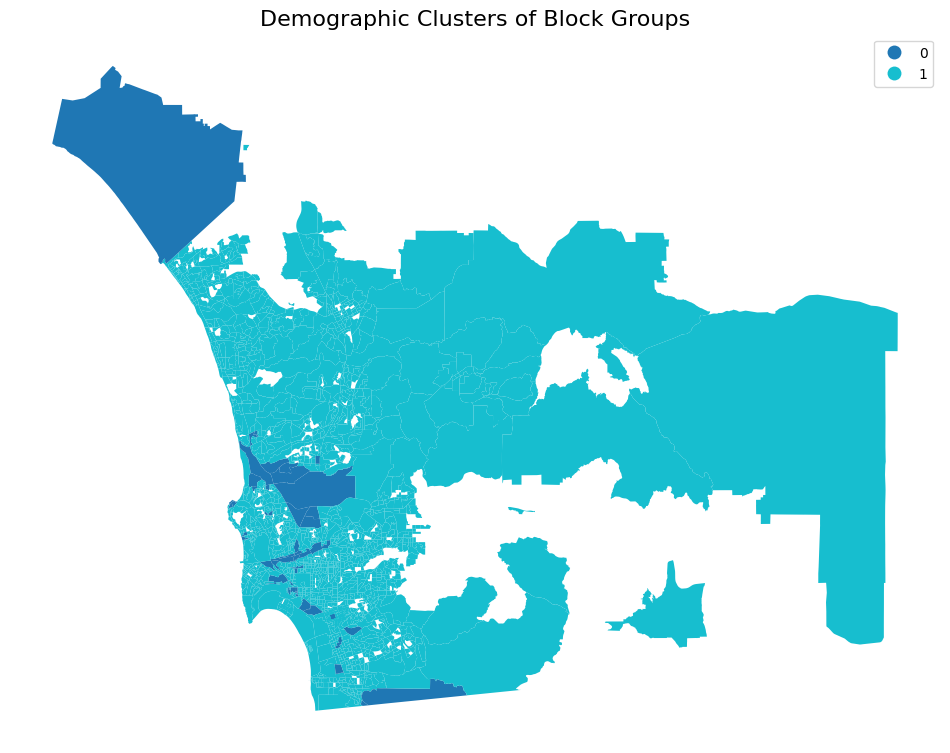

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

features = [
    "male25",
    "male30",
    "male35",
    "fem25",
    "fem30",
    "fem35",
    "population",
    "n01_bus",
    "n14_bus",
    "n35_bus",
    "n37_sales",
    "s16_sales",
    "s22_bus",
    "s23_emp"
    # "education_index",
    # "unemployment_rate",
    # "pop_density",
    # etc...
]

X = gdf[features].fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

scores = {}
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42).fit(X_scaled)
    scores[k] = silhouette_score(X_scaled, km.labels_)

print(scores)

optimal_k = max(scores, key=scores.get)
print(f"Optimal number of clusters: {optimal_k}")
    
km = KMeans(n_clusters=optimal_k, random_state=42)
gdf["cluster"] = km.fit_predict(X_scaled)

fig, ax = plt.subplots(1, 1, figsize=(12, 12))

gdf.plot(
    column="cluster",
    categorical=True,
    cmap="tab10",
    linewidth=0,
    edgecolor="none",
    legend=True,
    ax=ax
)

ax.set_title("Demographic Clusters of Block Groups", fontsize=16)
ax.axis("off")

plt.show()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


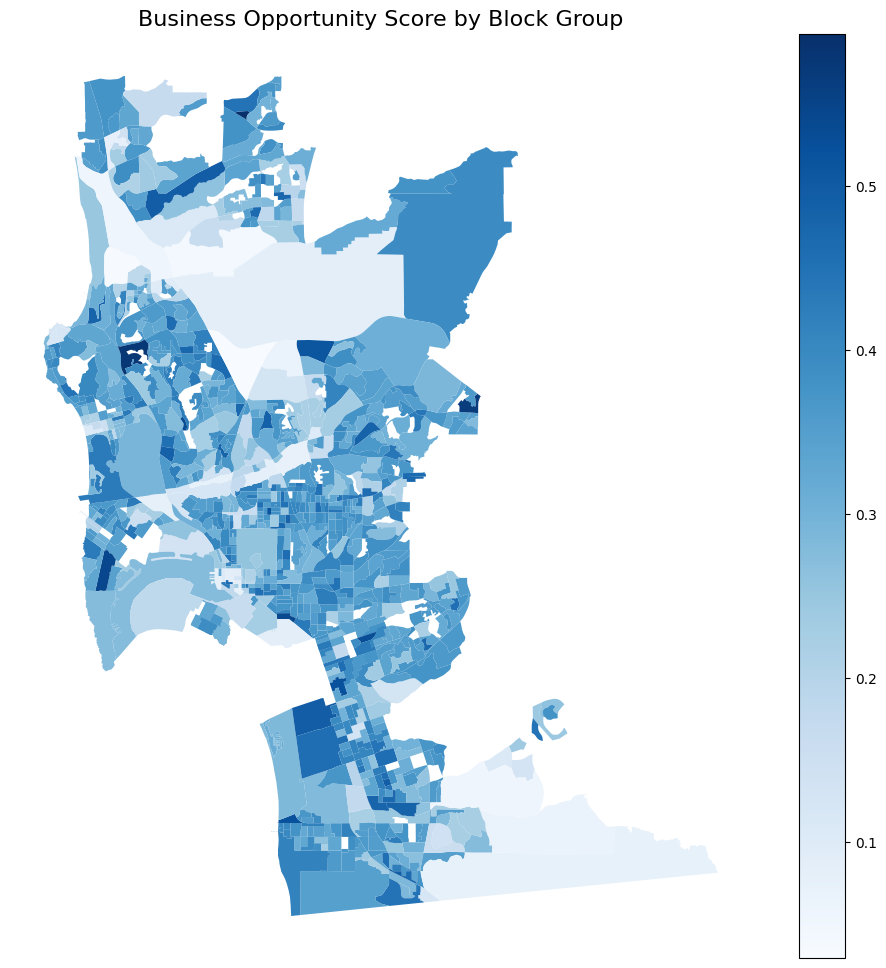

In [8]:
from sklearn.preprocessing import StandardScaler


demographic_features = [
    "male25",
    "male30",
    "male35",
    "fem25",
    "fem30",
    "fem35",
    "population",
    "n01_bus",
    "n14_bus",
    "n35_bus",
    "n37_sales",
    "s16_sales",
    "s22_bus",
    "s23_emp"
    # "education_index",
    # "unemployment_rate",
    # "pop_density",
    # etc...
]

threshold = gdf["business_success_score"].quantile(0.80)
gdf["is_successful"] = (gdf["business_success_score"] >= threshold).astype(int)

success_df = gdf[gdf["is_successful"] == 1]
success_centroid = success_df[demographic_features].mean().values


scaler = StandardScaler()
scaled_demo = scaler.fit_transform(gdf[demographic_features])

gdf_scaled = gdf.copy()
gdf_scaled[demographic_features] = scaled_demo

# scale the success centroid
success_centroid_scaled = scaler.transform([success_centroid])[0]

import numpy as np

def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b)**2))

gdf_scaled["distance_to_success"] = gdf_scaled[demographic_features].apply(
    lambda row: euclidean_distance(row.values, success_centroid_scaled),
    axis=1
)

gdf_scaled["business_opportunity_score"] = 1 / (1 + gdf_scaled["distance_to_success"])


import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(12, 12))

gdf_scaled.plot(
    column="business_opportunity_score",
    cmap="Blues",             # single-hue blue gradient
    linewidth=0,
    edgecolor="none",
    legend=True,
    ax=ax
)

ax.set_title("Business Opportunity Score by Block Group", fontsize=16)
ax.axis("off")

plt.show()


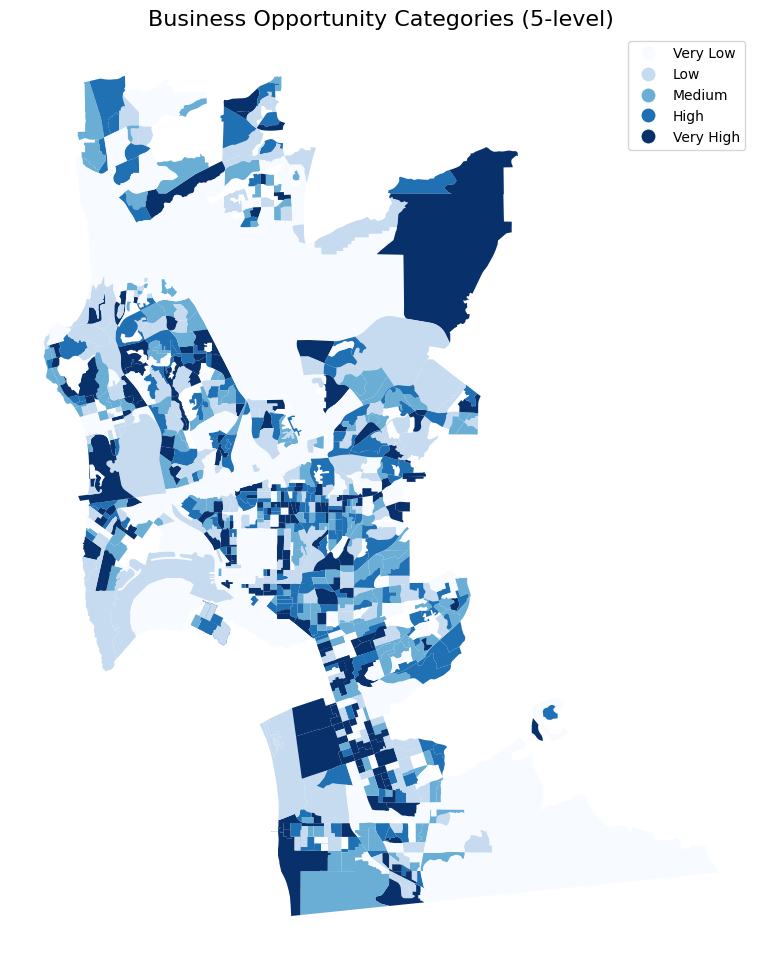

In [9]:
gdf_scaled["opp_category"] = pd.qcut(
    gdf_scaled["business_opportunity_score"],
    q=5,
    labels=["Very Low", "Low", "Medium", "High", "Very High"]
)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(12, 12))

gdf_scaled.plot(
    column="opp_category",
    categorical=True,
    cmap="Blues",
    linewidth=0,
    edgecolor="none",
    legend=True,
    ax=ax
)

ax.set_title("Business Opportunity Categories (5-level)", fontsize=16)
ax.axis("off")

plt.show()